# Lagos Urban Air Quality Clustering Using Unsupervised Machine Learning

## Project Overview
This notebook analyzes 2024 air quality sensor data from Lagos, Nigeria using three unsupervised machine learning algorithms:
- **K-Means Clustering**: Partitioning-based approach
- **DBSCAN**: Density-based approach that identifies outliers
- **Hierarchical Clustering**: Agglomerative approach

The data is transformed from long format (with value_type column) to wide format (individual columns for each measurement type), then analyzed to identify air quality patterns and pollution hotspots across Lagos.

In [ ]:

# PARAMETERS (Papermill injects values here at runtime)
# Tag this cell as "parameters" in Jupyter:

# overridden by run_pipeline.py
MONTH_LABEL = ""
DATA_PATH   = ""
RESULTS_PATH = ""

# 1. Initialization & Setup

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Machine learning and clustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# Evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


# 2. Data Loading

In [ ]:
# Load data from path injected by run_pipeline.py
data = pd.read_csv(DATA_PATH, sep=None, engine="python")
data['value'] = pd.to_numeric(data['value'], errors='coerce')

print(f"✓ Loaded {len(data):,} records from {DATA_PATH}")
print(f"\nDataset shape     : {data.shape}")
print(f"Column names      : {data.columns.tolist()}")
print(f"\nFirst 10 rows (LONG FORMAT):")
print(data.head(10))
print(f"Unique value_types: {data['value_type'].unique()}")
print(f"\nValue type counts:\n{data['value_type'].value_counts()}")

Found 12 monthly data files:
  ✓ April 2024.csv: 35,538 records
  ✓ August 2024.csv: 41,280 records
  ✓ December 2024.csv: 1,268 records
  ✓ February 2024.csv: 21,097 records
  ✓ January 2024.csv: 14,307 records
  ✓ July 2024.csv: 29,875 records
  ✓ June 2024.csv: 9,622 records
  ✓ March 2024.csv: 48,809 records
  ✓ May 2024.csv: 14,794 records
  ✓ November 2024.csv: 4,682 records
  ✓ October 2024.csv: 5,421 records
  ✓ September 2024.csv: 13,754 records

✓ Total records loaded: 240,447

Dataset shape: (240447, 9)

Column names: ['sensor_id', 'sensor_type', 'location', 'lat', 'lon', 'timestamp', 'value_type', 'value', 'source_file']


# 3. Data Transformation: Long to Wide Format

Transform the data so each value_type (P0, P1, P2, humidity, temperature) becomes its own column.

In [8]:
# Convert timestamp to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')

# Drop rows with critical missing values
print(f"Original shape: {data.shape}")
data = data.dropna(subset=['timestamp', 'lat', 'lon', 'value', 'sensor_id'])
print(f"After dropping critical NaNs: {data.shape}")

# Remove exact duplicates
data = data.drop_duplicates()
print(f"After removing duplicates: {data.shape}")

Original shape: (240447, 9)
After dropping critical NaNs: (240447, 9)
After removing duplicates: (240447, 9)


In [9]:
# PIVOT from long to wide format
# Index: sensor_id, location, lat, lon, timestamp
# Columns: each value_type (P0, P1, P2, humidity, temperature)
# Values: the measurement values

wide_df = data.pivot_table(
    index=['sensor_id', 'location', 'lat', 'lon', 'timestamp'],
    columns='value_type',
    values='value',
    aggfunc='mean'
).reset_index()

print(f"After pivot (WIDE FORMAT): {wide_df.shape}")
print(f"\nColumns in wide format: {wide_df.columns.tolist()}")
print(f"\nFirst 5 rows (WIDE FORMAT):")
print(wide_df.head())

After pivot (WIDE FORMAT): (94679, 10)

Columns in wide format: ['sensor_id', 'location', 'lat', 'lon', 'timestamp', 'P0', 'P1', 'P2', 'humidity', 'temperature']

First 5 rows (WIDE FORMAT):
value_type  sensor_id  location    lat  lon                        timestamp  \
0                4851      3627  6.515  3.4 2024-02-01 16:31:44.331333+00:00   
1                4851      3627  6.515  3.4 2024-02-01 16:38:14.403956+00:00   
2                4851      3627  6.515  3.4 2024-02-07 09:21:41.990049+00:00   
3                4851      3627  6.515  3.4 2024-02-07 09:22:47.488001+00:00   
4                4851      3627  6.515  3.4 2024-02-07 09:23:53.852311+00:00   

value_type     P0      P1      P2  humidity  temperature  
0           35.71   68.71   53.57       NaN          NaN  
1           39.78   72.00   56.89       NaN          NaN  
2           24.90   48.90   38.40       NaN          NaN  
3           27.00   52.33   39.33       NaN          NaN  
4           78.33  141.67  122.33

In [10]:
# Rename columns for clarity
# P0 -> PM1 (ultrafine particles)
# P1 -> PM2_5 (fine particles, health-critical)
# P2 -> PM10 (coarse particles)

wide_df = wide_df.rename(columns={
    'P0': 'PM1',
    'P1': 'PM2_5',
    'P2': 'PM10'
})

print(f"After renaming: {wide_df.columns.tolist()}")
print(f"\nShape: {wide_df.shape}")
print(f"\nMissing values per column:")
print(wide_df.isnull().sum())

After renaming: ['sensor_id', 'location', 'lat', 'lon', 'timestamp', 'PM1', 'PM2_5', 'PM10', 'humidity', 'temperature']

Shape: (94679, 10)

Missing values per column:
value_type
sensor_id          0
location           0
lat                0
lon                0
timestamp          0
PM1            43585
PM2_5          42381
PM10           42379
humidity       52300
temperature    52303
dtype: int64


In [11]:
# Handle missing values intelligently
feature_cols = ['PM1', 'PM2_5', 'PM10', 'humidity', 'temperature']

# Sort by sensor and timestamp for forward fill
wide_df = wide_df.sort_values(['sensor_id', 'timestamp'])

# Forward fill per sensor (preserves temporal continuity within each sensor)
wide_df[feature_cols] = wide_df.groupby('sensor_id')[feature_cols].fillna(method='ffill')

# Backward fill remaining
wide_df[feature_cols] = wide_df.groupby('sensor_id')[feature_cols].fillna(method='bfill')

# Fill remaining with sensor median
for col in feature_cols:
    wide_df[col] = wide_df[col].fillna(wide_df.groupby('sensor_id')[col].transform('median'))

# Global fallback
wide_df[feature_cols] = wide_df[feature_cols].fillna(wide_df[feature_cols].median())

print(f"After imputation, missing values per column:")
print(wide_df[feature_cols].isnull().sum())
print(f"\nShape: {wide_df.shape}")

After imputation, missing values per column:
value_type
PM1            0
PM2_5          0
PM10           0
humidity       0
temperature    0
dtype: int64

Shape: (94679, 10)


In [12]:
# Remove physically impossible and extreme values
print(f"Shape before outlier removal: {wide_df.shape}")

# Remove negative values (impossible for sensor readings)
wide_df = wide_df[
    (wide_df['PM1'] >= 0) &
    (wide_df['PM2_5'] >= 0) &
    (wide_df['PM10'] >= 0) &
    (wide_df['humidity'] >= 0) &
    (wide_df['humidity'] <= 100) &
    (wide_df['temperature'] >= -50) &
    (wide_df['temperature'] <= 70)
]

print(f"After removing invalid ranges: {wide_df.shape}")

# Clip extreme upper values (99th percentile)
for col in ['PM1', 'PM2_5', 'PM10']:
    q99 = wide_df[col].quantile(0.99)
    wide_df[col] = np.clip(wide_df[col], None, q99)

print(f"After percentile clipping: {wide_df.shape}")
print(f"\nData statistics:")
print(wide_df[feature_cols].describe())

Shape before outlier removal: (94679, 10)
After removing invalid ranges: (94345, 10)
After percentile clipping: (94345, 10)

Data statistics:
value_type           PM1         PM2_5          PM10      humidity  \
count       94345.000000  94345.000000  94345.000000  94345.000000   
mean           19.995697     32.848879     29.597148     69.676822   
std             9.294918     17.037717     14.673522     12.443063   
min             0.000000      0.000000      0.000000     18.800000   
25%            18.000000     28.000000     26.000000     65.000000   
50%            19.000000     30.000000     28.000000     68.700000   
75%            20.000000     32.000000     29.500000     73.400000   
max            70.000000    121.000000    110.140000    100.000000   

value_type   temperature  
count       94345.000000  
mean           34.097858  
std             3.528324  
min            23.000000  
25%            32.800000  
50%            33.900000  
75%            35.200000  
max        

# 4. Feature Engineering

In [13]:
# Extract temporal features
wide_df['hour'] = wide_df['timestamp'].dt.hour
wide_df['day_of_week'] = wide_df['timestamp'].dt.dayofweek
wide_df['month'] = wide_df['timestamp'].dt.month
wide_df['is_weekend'] = wide_df['day_of_week'].isin([5, 6]).astype(int)

# Cyclical encoding for hour (improves clustering)
wide_df['hour_sin'] = np.sin(2 * np.pi * wide_df['hour'] / 24)
wide_df['hour_cos'] = np.cos(2 * np.pi * wide_df['hour'] / 24)

# Create pollutant-derived features
wide_df['PM_total'] = wide_df['PM1'] + wide_df['PM2_5'] + wide_df['PM10']
wide_df['fine_ratio'] = wide_df['PM2_5'] / (wide_df['PM10'] + 1e-6)  # >1 = combustion, <1 = dust
wide_df['coarse_ratio'] = wide_df['PM10'] / (wide_df['PM2_5'] + 1e-6)  # Inverse ratio

# Weather interaction features
wide_df['PM_humidity_interaction'] = wide_df['PM2_5'] * wide_df['humidity'] / 100
wide_df['PM_temp_interaction'] = wide_df['PM2_5'] * (wide_df['temperature'] + 50) / 100

print(f"After feature engineering: {wide_df.shape}")
print(f"\nNew columns: {[col for col in wide_df.columns if col not in data.columns]}")

After feature engineering: (94345, 21)

New columns: ['PM1', 'PM2_5', 'PM10', 'humidity', 'temperature', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'PM_total', 'fine_ratio', 'coarse_ratio', 'PM_humidity_interaction', 'PM_temp_interaction']


In [ ]:
# Aggregate to daily level for clustering
# Calculate date without time
wide_df['date'] = wide_df['timestamp'].dt.date

# Define features to aggregate
agg_features = ['PM1', 'PM2_5', 'PM10', 'PM_total', 'fine_ratio', 'coarse_ratio', 
                 'humidity', 'temperature', 'PM_humidity_interaction', 'PM_temp_interaction']

# Group by sensor, location, coordinates, and date - take daily mean
daily_df = wide_df.groupby(['sensor_id', 'location', 'lat', 'lon', 'date'])[agg_features].mean().reset_index()

print(f"After daily aggregation: {daily_df.shape}")
print(f"\nDaily data sample:")
print(daily_df.head(10))

After daily aggregation: (621, 15)

Daily data sample:
value_type  sensor_id  location    lat  lon        date        PM1  \
0                4851      3627  6.515  3.4  2024-02-01  37.745000   
1                4851      3627  6.515  3.4  2024-02-07  59.082457   
2                4851      3627  6.515  3.4  2024-02-19  25.237632   
3                4851      3627  6.515  3.4  2024-02-21  34.854342   
4                4851      3627  6.515  3.4  2024-02-23  40.307029   
5                4851      3627  6.515  3.4  2024-02-25  30.744537   
6                4851      3627  6.515  3.4  2024-02-27  21.625713   
7                4851      3627  6.515  3.4  2024-02-28  20.668955   
8                4851      3627  6.515  3.4  2024-02-29  18.275918   
9                4851      3627  6.515  3.4  2024-04-02  12.867768   

value_type       PM2_5       PM10    PM_total  fine_ratio  coarse_ratio  \
0            70.355000  55.230000  163.330000    1.274111      0.784896   
1           108.725714  

In [15]:
# Create a composite pollution index (standardized average of PM metrics)
scaler_temp = StandardScaler()
pm_features = ['PM1', 'PM2_5', 'PM10']
pm_scaled = scaler_temp.fit_transform(daily_df[pm_features])
daily_df['pollution_index'] = pm_scaled.mean(axis=1)

# Define Air Quality Categories based on EPA standards
def categorize_aqi(pm25):
    if pm25 <= 12:
        return 'Good'
    elif pm25 <= 35:
        return 'Moderate'
    elif pm25 <= 55:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150:
        return 'Unhealthy'
    else:
        return 'Very Unhealthy'

daily_df['aqi_category'] = daily_df['PM2_5'].apply(categorize_aqi)

print(f"Final daily dataset shape: {daily_df.shape}")
print(f"\nAir Quality Category distribution:")
print(daily_df['aqi_category'].value_counts())

Final daily dataset shape: (621, 17)

Air Quality Category distribution:
aqi_category
Moderate                          426
Unhealthy for Sensitive Groups    112
Unhealthy                          76
Good                                7
Name: count, dtype: int64


# 5. Clustering Preparation

In [16]:
# Select features for clustering
cluster_features = ['PM1', 'PM2_5', 'PM10', 'fine_ratio', 'humidity', 'temperature']
X = daily_df[cluster_features].copy()

# Standardize features (critical for fair clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features used for clustering: {cluster_features}")
print(f"\nScaled data statistics:")
print(f"Mean: {X_scaled.mean(axis=0).round(3)}")
print(f"Std:  {X_scaled.std(axis=0).round(3)}")

Feature matrix shape: (621, 6)
Features used for clustering: ['PM1', 'PM2_5', 'PM10', 'fine_ratio', 'humidity', 'temperature']

Scaled data statistics:
Mean: [ 0.  0. -0. -0.  0.  0.]
Std:  [1. 1. 1. 1. 1. 1.]


In [17]:
# Reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA 2D projection shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\nPCA loadings (first 3 features):")
for i, feature in enumerate(cluster_features):
    print(f"  {feature:20s}: PC1={pca.components_[0][i]:6.3f}, PC2={pca.components_[1][i]:6.3f}")

PCA 2D projection shape: (621, 2)
Explained variance ratio: [0.57239845 0.31437993]
Cumulative explained variance: 88.68%

PCA loadings (first 3 features):
  PM1                 : PC1= 0.503, PC2= 0.236
  PM2_5               : PC1= 0.518, PC2= 0.198
  PM10                : PC1= 0.502, PC2= 0.241
  fine_ratio          : PC1= 0.375, PC2=-0.214
  humidity            : PC1=-0.199, PC2= 0.629
  temperature         : PC1= 0.215, PC2=-0.636


# 6. K-Means Clustering

In [18]:
# Elbow method to find optimal K
inertias = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, n_init=30, random_state=42, max_iter=500)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

print("Elbow Method - Inertia values:")
for k, inertia in zip(ks, inertias):
    print(f"  K={k}: {inertia:.2f}")

Elbow Method - Inertia values:
  K=2: 2141.32
  K=3: 1444.99
  K=4: 1046.19
  K=5: 813.29
  K=6: 698.66
  K=7: 599.87
  K=8: 518.22
  K=9: 452.19
  K=10: 402.35


In [19]:
# Evaluate metrics for each K
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=30, random_state=42, max_iter=500)
    labels = km.fit_predict(X_scaled)
    
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))

print("\nK-Means Evaluation Metrics:")
print(f"{'K':<3} {'Silhouette':<12} {'Davies-Bouldin':<15} {'Calinski-Harabasz':<18}")
print("-" * 50)
for i, k in enumerate(ks):
    print(f"{k:<3} {silhouette_scores[i]:<12.4f} {davies_bouldin_scores[i]:<15.4f} {calinski_harabasz_scores[i]:<18.2f}")

# Find optimal K based on silhouette score
optimal_k_kmeans = ks[np.argmax(silhouette_scores)]
print(f"\nOptimal K (by Silhouette): {optimal_k_kmeans}")


K-Means Evaluation Metrics:
K   Silhouette   Davies-Bouldin  Calinski-Harabasz 
--------------------------------------------------
2   0.4891       0.9282          458.09            
3   0.3817       0.8590          487.78            
4   0.3978       0.8510          526.82            
5   0.4028       0.8922          551.53            
6   0.4148       0.9429          532.97            
7   0.4204       0.8360          533.30            
8   0.4140       0.8131          542.07            
9   0.4204       0.8026          553.86            
10  0.4124       0.7924          560.80            

Optimal K (by Silhouette): 2


In [20]:
# Fit K-Means with optimal K
kmeans = KMeans(n_clusters=optimal_k_kmeans, n_init=30, random_state=42, max_iter=500)
daily_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means with K={optimal_k_kmeans} fitted and assigned to daily_df")
print(f"\nCluster distribution:")
print(daily_df['kmeans_cluster'].value_counts().sort_index())

K-Means with K=2 fitted and assigned to daily_df

Cluster distribution:
kmeans_cluster
0    495
1    126
Name: count, dtype: int64


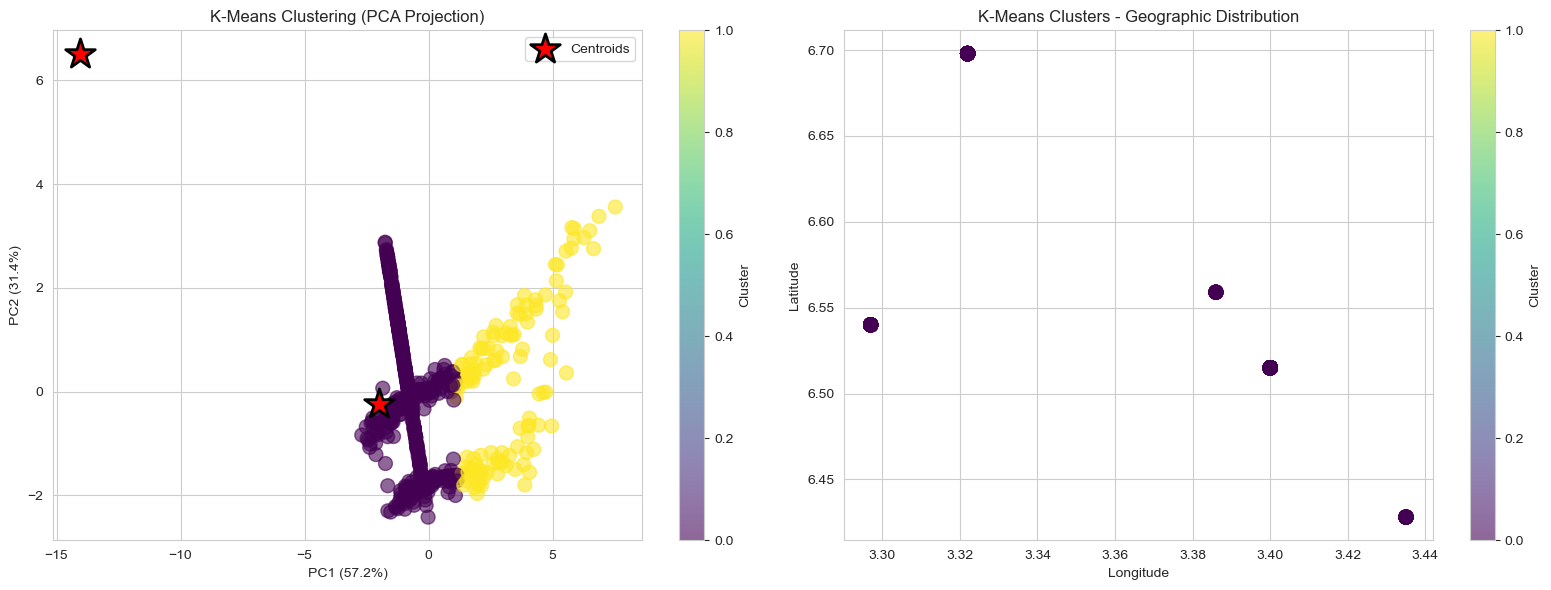

K-Means visualizations complete


In [21]:
# Visualize K-Means results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA projection
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=daily_df['kmeans_cluster'], 
                           cmap='viridis', alpha=0.6, s=100)
axes[0].scatter(pca.transform(scaler.transform(kmeans.cluster_centers_))[:, 0],
               pca.transform(scaler.transform(kmeans.cluster_centers_))[:, 1],
               c='red', marker='*', s=500, edgecolors='black', linewidths=2, label='Centroids')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('K-Means Clustering (PCA Projection)')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Geographic distribution
scatter2 = axes[1].scatter(daily_df['lon'], daily_df['lat'], c=daily_df['kmeans_cluster'],
                           cmap='viridis', alpha=0.6, s=100)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('K-Means Clusters - Geographic Distribution')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

print("K-Means visualizations complete")

# 7. DBSCAN Clustering

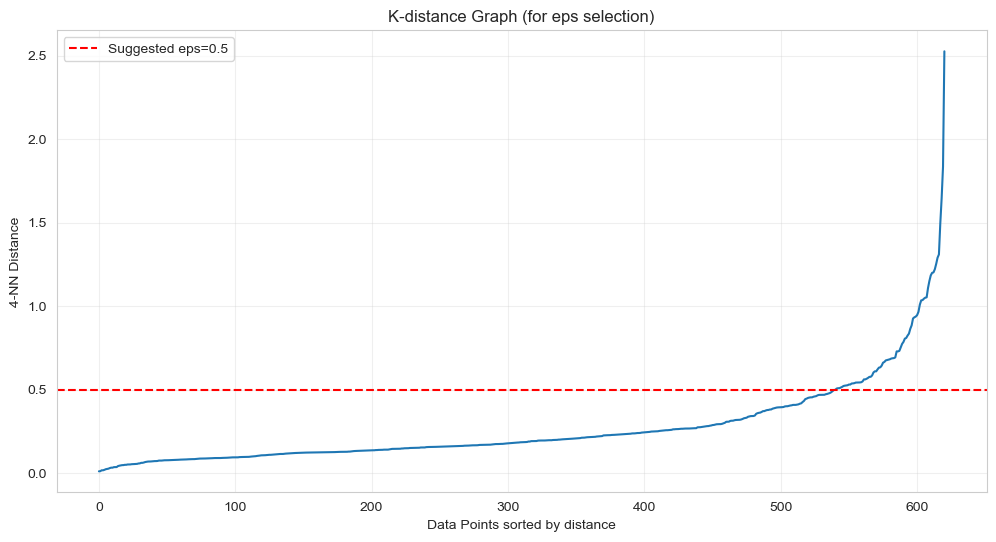

K-distance statistics:
  Min: 0.013
  25th percentile: 0.125
  Median: 0.187
  75th percentile: 0.316
  Max: 2.527


In [22]:
# K-distance graph for eps parameter selection
from sklearn.neighbors import NearestNeighbors

k = 4  # min_samples reference
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{k}-NN Distance')
plt.title('K-distance Graph (for eps selection)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', label='Suggested eps=0.5')
plt.legend()
plt.show()

print(f"K-distance statistics:")
print(f"  Min: {distances.min():.3f}")
print(f"  25th percentile: {np.percentile(distances, 25):.3f}")
print(f"  Median: {np.median(distances):.3f}")
print(f"  75th percentile: {np.percentile(distances, 75):.3f}")
print(f"  Max: {distances.max():.3f}")

In [23]:
# Parameter grid search for DBSCAN
eps_values = [0.3, 0.5, 0.7, 1.0, 1.3]
min_samples_values = [3, 5, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Silhouette only valid if more than 1 cluster and not all noise
        if n_clusters > 1 and n_noise < len(labels):
            mask = labels != -1
            if mask.sum() > 1:
                sil_score = silhouette_score(X_scaled[mask], labels[mask])
            else:
                sil_score = -1
        else:
            sil_score = -1
        
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        })

dbscan_df = pd.DataFrame(dbscan_results)
print("DBSCAN Parameter Grid Search:")
print(dbscan_df.to_string())

# Select best based on silhouette score and reasonable cluster count
valid_results = dbscan_df[(dbscan_df['n_clusters'] > 1) & (dbscan_df['silhouette'] > 0)]
if len(valid_results) > 0:
    best_idx = valid_results['silhouette'].idxmax()
    best_eps = dbscan_df.loc[best_idx, 'eps']
    best_min_samples = dbscan_df.loc[best_idx, 'min_samples']
    print(f"\nBest DBSCAN parameters: eps={best_eps}, min_samples={best_min_samples}")
else:
    best_eps, best_min_samples = 0.7, 5
    print(f"\nUsing default DBSCAN parameters: eps={best_eps}, min_samples={best_min_samples}")

DBSCAN Parameter Grid Search:
    eps  min_samples  n_clusters  n_noise  silhouette
0   0.3            3          10      109   -0.065380
1   0.3            5           8      140    0.032994
2   0.3           10           5      260    0.246026
3   0.5            3           8       38    0.146959
4   0.5            5           2       75    0.408498
5   0.5           10           1      122   -1.000000
6   0.7            3           3       18    0.453094
7   0.7            5           4       26    0.402897
8   0.7           10           1       71   -1.000000
9   1.0            3           3        5    0.427976
10  1.0            5           1       15   -1.000000
11  1.0           10           1       27   -1.000000
12  1.3            3           1        1   -1.000000
13  1.3            5           1        2   -1.000000
14  1.3           10           2        6    0.612991

Best DBSCAN parameters: eps=1.3, min_samples=10


In [24]:
# Fit optimal DBSCAN
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
daily_df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(f"DBSCAN fitted with eps={best_eps}, min_samples={best_min_samples}")
print(f"\nCluster distribution:")
unique_labels = sorted(daily_df['dbscan_cluster'].unique())
for label in unique_labels:
    count = (daily_df['dbscan_cluster'] == label).sum()
    cluster_type = 'Noise' if label == -1 else f'Cluster {label}'
    print(f"  {cluster_type}: {count} points ({count/len(daily_df)*100:.1f}%)")

DBSCAN fitted with eps=1.3, min_samples=10

Cluster distribution:
  Noise: 6 points (1.0%)
  Cluster 0: 603 points (97.1%)
  Cluster 1: 12 points (1.9%)


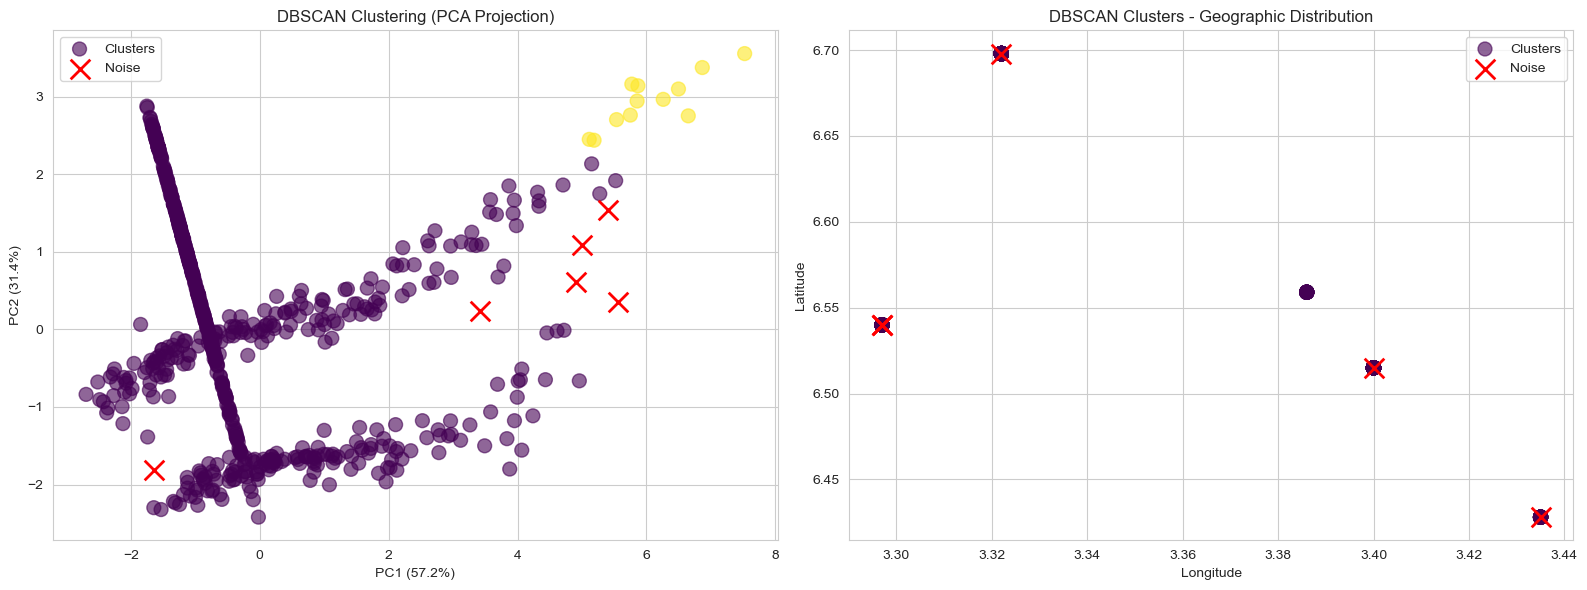

DBSCAN visualizations complete


In [25]:
# Visualize DBSCAN results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA projection (noise marked differently)
noise_mask = daily_df['dbscan_cluster'] == -1
cluster_mask = ~noise_mask

axes[0].scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], 
               c=daily_df.loc[cluster_mask, 'dbscan_cluster'], 
               cmap='viridis', alpha=0.6, s=100, label='Clusters')
axes[0].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='red', marker='x', s=200, linewidths=2, label='Noise')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('DBSCAN Clustering (PCA Projection)')
axes[0].legend()

# Geographic distribution
axes[1].scatter(daily_df.loc[cluster_mask, 'lon'], daily_df.loc[cluster_mask, 'lat'],
               c=daily_df.loc[cluster_mask, 'dbscan_cluster'], 
               cmap='viridis', alpha=0.6, s=100, label='Clusters')
axes[1].scatter(daily_df.loc[noise_mask, 'lon'], daily_df.loc[noise_mask, 'lat'],
               c='red', marker='x', s=200, linewidths=2, label='Noise')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('DBSCAN Clusters - Geographic Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print("DBSCAN visualizations complete")

# 8. Hierarchical Clustering

In [26]:
# Compare different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']
hierarchical_results = []

for method in linkage_methods:
    Z = linkage(X_scaled, method=method)
    
    for n_clusters in [3, 4, 5]:
        labels = fcluster(Z, n_clusters, criterion='maxclust') - 1
        sil = silhouette_score(X_scaled, labels)
        
        hierarchical_results.append({
            'linkage': method,
            'n_clusters': n_clusters,
            'silhouette': sil
        })

hierarchical_df = pd.DataFrame(hierarchical_results)
print("Hierarchical Clustering - Linkage Comparison:")
print(hierarchical_df.pivot(index='linkage', columns='n_clusters', values='silhouette').round(4))

# Use Ward linkage (generally best for clustering)
print("\nUsing Ward linkage method")

Hierarchical Clustering - Linkage Comparison:
n_clusters       3       4       5
linkage                           
average     0.4968  0.3185  0.3008
complete    0.4055  0.3713  0.3664
single      0.3265  0.3039  0.3022
ward        0.3598  0.3714  0.3768

Using Ward linkage method


In [27]:
# Find optimal number of clusters with Ward linkage
Z_ward = linkage(X_scaled, method='ward')

hier_metrics = []
for n_clusters in range(2, 10):
    labels = fcluster(Z_ward, n_clusters, criterion='maxclust') - 1
    
    hier_metrics.append({
        'n_clusters': n_clusters,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels)
    })

hier_metrics_df = pd.DataFrame(hier_metrics)
print("Hierarchical Clustering - Optimal Cluster Count:")
print(hier_metrics_df.to_string())

optimal_n_hier = hier_metrics_df.loc[hier_metrics_df['silhouette'].idxmax(), 'n_clusters']
print(f"\nOptimal number of clusters (by Silhouette): {optimal_n_hier}")

Hierarchical Clustering - Optimal Cluster Count:
   n_clusters  silhouette  davies_bouldin  calinski_harabasz
0           2    0.527807        0.784662         375.184242
1           3    0.359772        0.805712         438.264400
2           4    0.371393        0.980177         484.300436
3           5    0.376815        0.954655         472.981398
4           6    0.379262        0.910195         484.700604
5           7    0.406892        0.844873         493.625754
6           8    0.382761        0.805261         483.037965
7           9    0.388187        0.900102         485.843623

Optimal number of clusters (by Silhouette): 2


In [28]:
# Fit hierarchical clustering with optimal clusters
daily_df['hierarchical_cluster'] = fcluster(Z_ward, optimal_n_hier, criterion='maxclust') - 1

print(f"Hierarchical clustering fitted with {optimal_n_hier} clusters")
print(f"\nCluster distribution:")
print(daily_df['hierarchical_cluster'].value_counts().sort_index())

Hierarchical clustering fitted with 2 clusters

Cluster distribution:
hierarchical_cluster
0     69
1    552
Name: count, dtype: int64


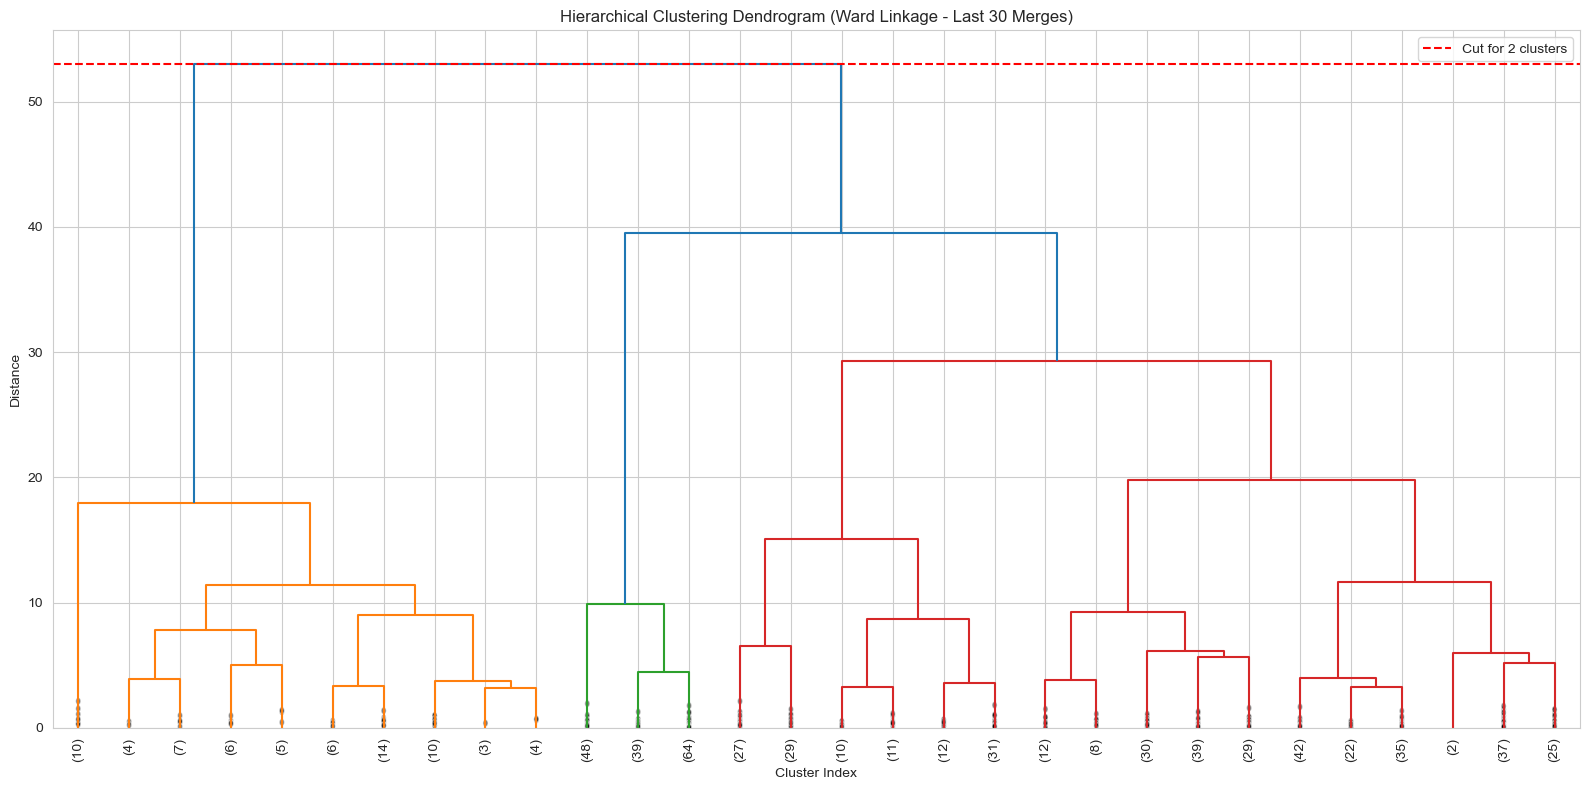

In [29]:
# Dendrogram visualization
plt.figure(figsize=(16, 8))
dendrogram(Z_ward, 
          truncate_mode='lastp',
          p=30,  # show last 30 merges
          leaf_rotation=90,
          leaf_font_size=10,
          show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage - Last 30 Merges)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.axhline(y=Z_ward[-optimal_n_hier+1, 2], c='red', linestyle='--', 
           label=f'Cut for {optimal_n_hier} clusters')
plt.legend()
plt.tight_layout()
plt.show()

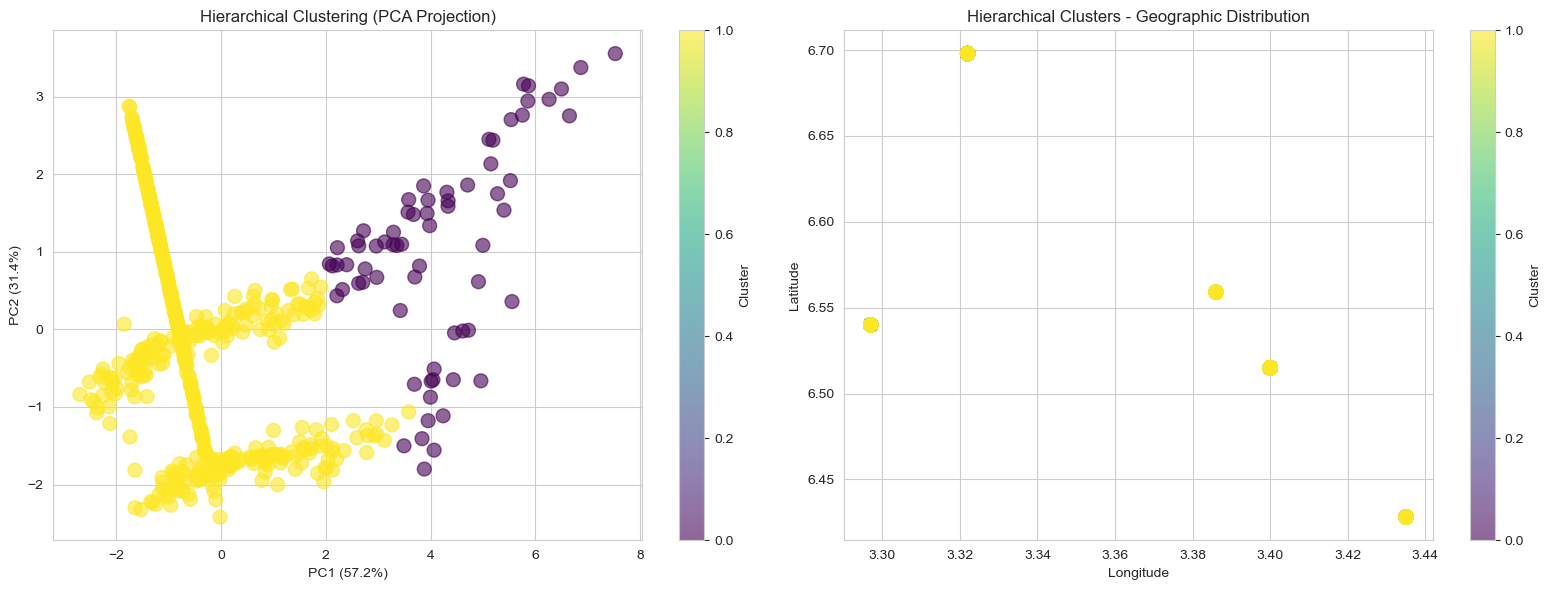

Hierarchical visualizations complete


In [30]:
# Visualize Hierarchical results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA projection
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=daily_df['hierarchical_cluster'], 
                           cmap='viridis', alpha=0.6, s=100)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Hierarchical Clustering (PCA Projection)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Geographic distribution
scatter2 = axes[1].scatter(daily_df['lon'], daily_df['lat'], c=daily_df['hierarchical_cluster'],
                           cmap='viridis', alpha=0.6, s=100)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Hierarchical Clusters - Geographic Distribution')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

print("Hierarchical visualizations complete")

# 9. Cluster Profiling & Analysis

In [31]:
# Profile K-Means clusters
print("=" * 80)
print("K-MEANS CLUSTER PROFILES")
print("=" * 80)

for cluster in sorted(daily_df['kmeans_cluster'].unique()):
    cluster_data = daily_df[daily_df['kmeans_cluster'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_data)} points, {len(cluster_data)/len(daily_df)*100:.1f}%)")
    print("-" * 80)
    print(f"  Locations: {cluster_data['location'].nunique()} unique")
    print(f"  PM1:       Mean={cluster_data['PM1'].mean():.2f}, Std={cluster_data['PM1'].std():.2f}")
    print(f"  PM2.5:     Mean={cluster_data['PM2_5'].mean():.2f}, Std={cluster_data['PM2_5'].std():.2f}")
    print(f"  PM10:      Mean={cluster_data['PM10'].mean():.2f}, Std={cluster_data['PM10'].std():.2f}")
    print(f"  Fine Ratio: Mean={cluster_data['fine_ratio'].mean():.3f} (>1=combustion, <1=dust)")
    print(f"  Humidity:  Mean={cluster_data['humidity'].mean():.1f}%")
    print(f"  Temperature: Mean={cluster_data['temperature'].mean():.1f}°C")
    print(f"  AQI Categories: {cluster_data['aqi_category'].value_counts().to_dict()}")

K-MEANS CLUSTER PROFILES

Cluster 0 (495 points, 79.7%)
--------------------------------------------------------------------------------
  Locations: 5 unique
  PM1:       Mean=18.29, Std=3.46
  PM2.5:     Mean=29.44, Std=6.03
  PM10:      Mean=26.89, Std=5.18
  Fine Ratio: Mean=1.091 (>1=combustion, <1=dust)
  Humidity:  Mean=70.1%
  Temperature: Mean=34.0°C
  AQI Categories: {'Moderate': 426, 'Unhealthy for Sensitive Groups': 62, 'Good': 7}

Cluster 1 (126 points, 20.3%)
--------------------------------------------------------------------------------
  Locations: 5 unique
  PM1:       Mean=35.85, Std=10.35
  PM2.5:     Mean=65.02, Std=18.22
  PM10:      Mean=55.10, Std=17.41
  Fine Ratio: Mean=1.195 (>1=combustion, <1=dust)
  Humidity:  Mean=62.3%
  Temperature: Mean=36.6°C
  AQI Categories: {'Unhealthy': 76, 'Unhealthy for Sensitive Groups': 50}


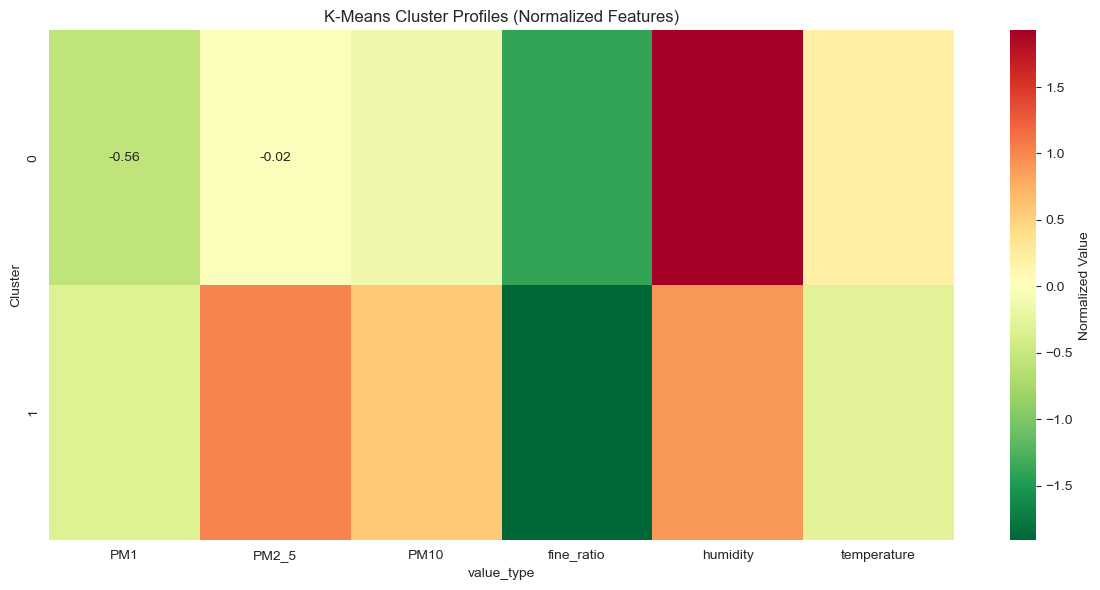

In [32]:
# Create cluster profile heatmap for K-Means
profile_features = ['PM1', 'PM2_5', 'PM10', 'fine_ratio', 'humidity', 'temperature']
cluster_profiles = daily_df.groupby('kmeans_cluster')[profile_features].mean()

# Normalize for heatmap visualization
scaler_viz = StandardScaler()
cluster_profiles_normalized = pd.DataFrame(
    scaler_viz.fit_transform(cluster_profiles.T).T,
    index=cluster_profiles.index,
    columns=cluster_profiles.columns
)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles_normalized, annot=True, fmt='.2f', cmap='RdYlGn_r', 
           cbar_kws={'label': 'Normalized Value'})
plt.title('K-Means Cluster Profiles (Normalized Features)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

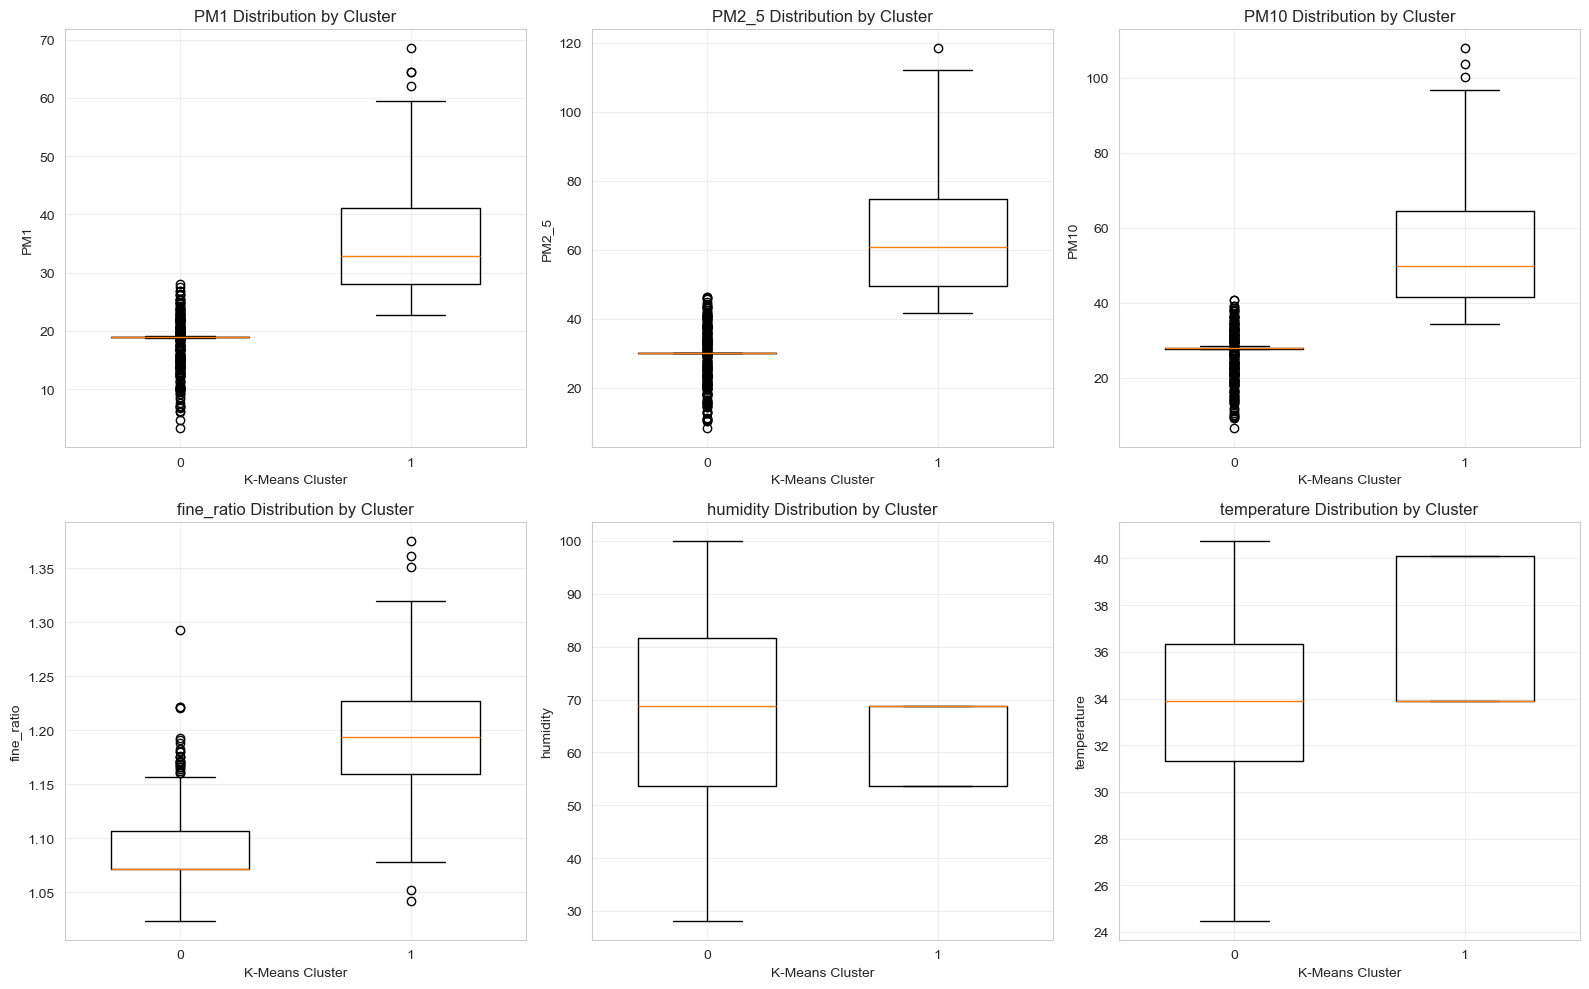

In [33]:
# Feature distributions by K-Means cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(profile_features):
    for cluster in sorted(daily_df['kmeans_cluster'].unique()):
        data_to_plot = daily_df[daily_df['kmeans_cluster'] == cluster][feature]
        axes[idx].boxplot(data_to_plot, positions=[cluster], widths=0.6)
    
    axes[idx].set_title(f'{feature} Distribution by Cluster')
    axes[idx].set_xlabel('K-Means Cluster')
    axes[idx].set_ylabel(feature)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Algorithm Comparison

In [34]:
# Compute metrics for all three algorithms
comparison_data = []

# K-Means metrics
kmeans_labels = daily_df['kmeans_cluster'].values
comparison_data.append({
    'Algorithm': 'K-Means',
    'n_clusters': optimal_k_kmeans,
    'silhouette': silhouette_score(X_scaled, kmeans_labels),
    'davies_bouldin': davies_bouldin_score(X_scaled, kmeans_labels),
    'calinski_harabasz': calinski_harabasz_score(X_scaled, kmeans_labels)
})

# DBSCAN metrics (excluding noise)
dbscan_labels = daily_df['dbscan_cluster'].values
mask_dbscan = dbscan_labels != -1
if mask_dbscan.sum() > 1:
    comparison_data.append({
        'Algorithm': 'DBSCAN',
        'n_clusters': len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0),
        'silhouette': silhouette_score(X_scaled[mask_dbscan], dbscan_labels[mask_dbscan]),
        'davies_bouldin': davies_bouldin_score(X_scaled[mask_dbscan], dbscan_labels[mask_dbscan]),
        'calinski_harabasz': calinski_harabasz_score(X_scaled[mask_dbscan], dbscan_labels[mask_dbscan])
    })

# Hierarchical metrics
hier_labels = daily_df['hierarchical_cluster'].values
comparison_data.append({
    'Algorithm': 'Hierarchical',
    'n_clusters': optimal_n_hier,
    'silhouette': silhouette_score(X_scaled, hier_labels),
    'davies_bouldin': davies_bouldin_score(X_scaled, hier_labels),
    'calinski_harabasz': calinski_harabasz_score(X_scaled, hier_labels)
})

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 100)
print("ALGORITHM PERFORMANCE COMPARISON")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("\nNote: Higher Silhouette and Calinski-Harabasz scores are better.")
print("      Lower Davies-Bouldin score is better.")


ALGORITHM PERFORMANCE COMPARISON
   Algorithm  n_clusters  silhouette  davies_bouldin  calinski_harabasz
     K-Means           2    0.489128        0.928167         458.088622
      DBSCAN           2    0.612991        0.390303         130.141242
Hierarchical           2    0.527807        0.784662         375.184242

Note: Higher Silhouette and Calinski-Harabasz scores are better.
      Lower Davies-Bouldin score is better.


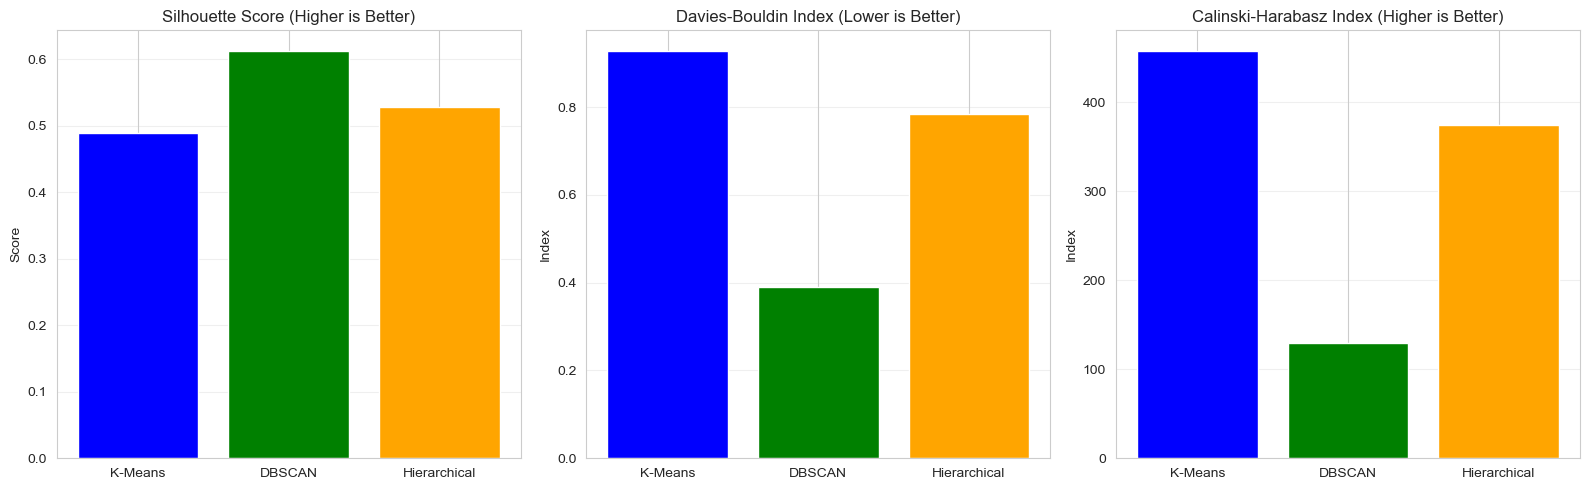

In [35]:
# Visualization: Algorithm Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Silhouette Score (higher is better)
axes[0].bar(comparison_df['Algorithm'], comparison_df['silhouette'], color=['blue', 'green', 'orange'])
axes[0].set_title('Silhouette Score (Higher is Better)')
axes[0].set_ylabel('Score')
axes[0].grid(True, alpha=0.3, axis='y')

# Davies-Bouldin Index (lower is better)
axes[1].bar(comparison_df['Algorithm'], comparison_df['davies_bouldin'], color=['blue', 'green', 'orange'])
axes[1].set_title('Davies-Bouldin Index (Lower is Better)')
axes[1].set_ylabel('Index')
axes[1].grid(True, alpha=0.3, axis='y')

# Calinski-Harabasz Index (higher is better)
axes[2].bar(comparison_df['Algorithm'], comparison_df['calinski_harabasz'], color=['blue', 'green', 'orange'])
axes[2].set_title('Calinski-Harabasz Index (Higher is Better)')
axes[2].set_ylabel('Index')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 11. Key Insights & Recommendations

In [ ]:
print("\n" + "=" * 100)
print("KEY INSIGHTS & ENVIRONMENTAL MANAGEMENT RECOMMENDATIONS")
print("=" * 100)

print("\n1. DATASET CHARACTERISTICS:")
print(f"   - Total observations: {len(daily_df)}")
print(f"   - Date range: {daily_df['date'].min()} to {daily_df['date'].max()}")
print(f"   - Unique sensors: {daily_df['sensor_id'].nunique()}")
print(f"   - Coverage locations: {daily_df['location'].nunique()}")
print(f"   - Features used: {', '.join(cluster_features)}")

print("\n2. AIR QUALITY OVERVIEW:")
print(f"   - Average PM2.5: {daily_df['PM2_5'].mean():.2f} µg/m³")
print(f"   - PM2.5 Range: {daily_df['PM2_5'].min():.2f} - {daily_df['PM2_5'].max():.2f} µg/m³")
print(f"   - Average PM10: {daily_df['PM10'].mean():.2f} µg/m³")
print(f"   - Humidity: {daily_df['humidity'].mean():.1f}% ± {daily_df['humidity'].std():.1f}%")
print(f"   - Temperature: {daily_df['temperature'].mean():.1f}°C ± {daily_df['temperature'].std():.1f}°C")

print("\n3. AQI CATEGORY DISTRIBUTION:")
for category in ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy']:
    count = (daily_df['aqi_category'] == category).sum()
    if count > 0:
        print(f"   - {category}: {count} days ({count/len(daily_df)*100:.1f}%)")

print("\n4. CLUSTERING EFFECTIVENESS:")
best_algo = comparison_df.loc[comparison_df['silhouette'].idxmax(), 'Algorithm']
print(f"   - Recommended algorithm: {best_algo}")
print(f"   - Best Silhouette Score: {comparison_df['silhouette'].max():.4f}")
print(f"   - Algorithm ranking (by Silhouette):")
for idx, row in comparison_df.sort_values('silhouette', ascending=False).iterrows():
    print(f"     {idx+1}. {row['Algorithm']}: {row['silhouette']:.4f} (clusters: {row['n_clusters']})")

print("\n5. POLLUTION HOTSPOTS (K-Means):")
high_pollution = daily_df.groupby('kmeans_cluster')['PM2_5'].mean().sort_values(ascending=False)
for rank, (cluster, pm25) in enumerate(high_pollution.head(3).items(), 1):
    cluster_locs = daily_df[daily_df['kmeans_cluster'] == cluster]['location'].value_counts()
    top_loc = cluster_locs.index[0]
    print(f"   {rank}. Cluster {cluster}: Avg PM2.5 = {pm25:.2f} µg/m³ (worst: {top_loc})")

print("\n6. ACTIONABLE RECOMMENDATIONS:")
print("   a) IMMEDIATE (Action within 1 month):")
print(f"      - Set targeted monitoring in top 3 pollution hotspots identified")
print(f"      - Alert systems for days exceeding Unhealthy threshold ({35:.2f} µg/m³)")
print(f"      - Identify emission sources in high fine_ratio clusters (combustion-related)")
print(f"\n   b) SHORT-TERM (1-3 months):")
print(f"      - Traffic restriction policies in high PM2.5 clusters")
print(f"      - Public health warnings for Unhealthy AQI days")
print(f"\n   c) LONG-TERM (3-12 months):")
print(f"      - Expand sensor network to undermonitored areas")
print(f"      - Analyze source apportionment using fine_ratio and coarse_ratio trends")
print(f"      - Develop predictive model for pollution forecasting")
print(f"      - Implement air quality improvement targets: reduce PM2.5 by 15%")


KEY INSIGHTS & ENVIRONMENTAL MANAGEMENT RECOMMENDATIONS

1. DATASET CHARACTERISTICS:
   - Total observations: 621
   - Date range: 2024-01-01 to 2024-12-28
   - Unique sensors: 10
   - Coverage locations: 5
   - Features used: PM1, PM2_5, PM10, fine_ratio, humidity, temperature

2. AIR QUALITY OVERVIEW:
   - Average PM2.5: 36.66 µg/m³
   - PM2.5 Range: 8.27 - 118.35 µg/m³
   - Average PM10: 32.62 µg/m³
   - Humidity: 68.5% ± 14.6%
   - Temperature: 34.5°C ± 4.0°C

3. AQI CATEGORY DISTRIBUTION:
   - Good: 7 days (1.1%)
   - Moderate: 426 days (68.6%)
   - Unhealthy for Sensitive Groups: 112 days (18.0%)
   - Unhealthy: 76 days (12.2%)

4. CLUSTERING EFFECTIVENESS:
   - Recommended algorithm: DBSCAN
   - Best Silhouette Score: 0.6130
   - Algorithm ranking (by Silhouette):
     2. DBSCAN: 0.6130 (clusters: 2)
     3. Hierarchical: 0.5278 (clusters: 2)
     1. K-Means: 0.4891 (clusters: 2)

5. POLLUTION HOTSPOTS (K-Means):
   1. Cluster 1: Avg PM2.5 = 65.02 µg/m³ (worst: 3917)
   2. Clus

KeyError: 'month'

In [ ]:
print("\n" + "=" * 100)
print("ANALYSIS COMPLETE")
print("=" * 100)
print(f"\nTotal observations analyzed: {len(daily_df)}")
print(f"\nNext steps:")
print(f"  1. Review cluster assignments and validate against domain knowledge")
print(f"  2. Cross-reference pollution hotspots with known industrial/traffic areas")
print(f"  3. Present findings to environmental management stakeholders")
print(f"  4. Implement monitoring and intervention strategies")

In [ ]:
import json

features = ['PM1', 'PM2_5', 'PM10', 'fine_ratio', 'humidity', 'temperature']

# Helper 
def build_centroids(df, cluster_col):
    """Compute mean of each feature per cluster label."""
    return [
        {
            "cluster": int(cluster),
            **{f: round(float(df[df[cluster_col] == cluster][f].mean()), 4) for f in features}
        }
        for cluster in sorted(df[cluster_col].unique())
    ]

# Pull metrics straight from comparison_df (already computed above) 
def get_metrics(algorithm_name):
    row = comparison_df[comparison_df['Algorithm'] == algorithm_name].iloc[0]
    return {
        "silhouette":        round(float(row['silhouette']), 4),
        "davies_bouldin":    round(float(row['davies_bouldin']), 4),
        "calinski_harabasz": round(float(row['calinski_harabasz']), 4),
    }

_dbscan_mask = daily_df['dbscan_cluster'] != -1

# Build results dict 
results = {
    "month_label": MONTH_LABEL,
    "kmeans": {
        "n_clusters": int(optimal_k_kmeans),
        **get_metrics("K-Means"),
        "centroids": build_centroids(daily_df, 'kmeans_cluster'),
    },
    "dbscan": {
        "n_clusters":  int(daily_df.loc[_dbscan_mask, 'dbscan_cluster'].nunique()),
        "eps":         float(best_eps),
        "min_samples": int(best_min_samples),
        "n_noise":     int((daily_df['dbscan_cluster'] == -1).sum()),
        **get_metrics("DBSCAN"),
        "centroids": build_centroids(daily_df[_dbscan_mask], 'dbscan_cluster'),
    },
    "hierarchical": {
        "n_clusters":     int(optimal_n_hier),
        "linkage_method": "ward",
        **get_metrics("Hierarchical"),
        "centroids": build_centroids(daily_df, 'hierarchical_cluster'),
    },
    "observations": [
        {
            "sensor_id":            int(row['sensor_id']),
            "location":             int(row['location']),
            "lat":                  float(row['lat']),
            "lon":                  float(row['lon']),
            "date":                 str(row['date']),
            "PM1":                  round(float(row['PM1']), 4),
            "PM2_5":                round(float(row['PM2_5']), 4),
            "PM10":                 round(float(row['PM10']), 4),
            "fine_ratio":           round(float(row['fine_ratio']), 4),
            "coarse_ratio":         round(float(row['coarse_ratio']), 4),
            "humidity":             round(float(row['humidity']), 4),
            "temperature":          round(float(row['temperature']), 4),
            "aqi_category":         row['aqi_category'],
            "kmeans_cluster":       int(row['kmeans_cluster']),
            "dbscan_cluster":       int(row['dbscan_cluster']),
            "hierarchical_cluster": int(row['hierarchical_cluster']),
        }
        for _, row in daily_df.iterrows()
    ]
}

# Write to results file 
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f)

print(f"✓ Results written to {RESULTS_PATH}")
print(f"  Observations : {len(results['observations'])}")
print(f"  K-Means      : {results['kmeans']['n_clusters']} clusters, silhouette={results['kmeans']['silhouette']}")
print(f"  DBSCAN       : {results['dbscan']['n_clusters']} clusters + {results['dbscan']['n_noise']} noise, silhouette={results['dbscan']['silhouette']}")
print(f"  Hierarchical : {results['hierarchical']['n_clusters']} clusters, silhouette={results['hierarchical']['silhouette']}")